In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\ADEKUNLE\Downloads\FE-GWP1_model_selection_1.csv")
df.head()

,Y,X1,X2,X3,X4,X5
0,3.388410,0.017954,-0.800583,-0.352454,2.187210,1.014887
1,0.287191,0.083057,-0.597947,-0.357639,-1.630284,0.221841
2,3.989645,-0.923437,-1.386575,1.180202,0.632606,-1.576638
3,-2.959602,-0.313775,2.955133,-1.798692,-2.117621,0.159291
4,0.529773,0.388996,1.019611,0.472062,0.590497,0.877048


**DATA EXPLORATION**

In [3]:
print(f"Dataset dimensions: {df.shape[0]} observations, {df.shape[1]} variables")
print()
print("Summary Statistics:")
print(df.describe())
print()

Dataset dimensions: 100 observations, 6 variables

Summary Statistics:
                Y          X1          X2          X3          X4          X5
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000
mean     1.257388    0.026830    0.084613   -0.016037    0.122374   -0.201661
std      1.436655    0.481708    0.962145    0.976559    1.076935    1.073358
min     -2.959602   -1.275230   -2.041959   -2.228483   -2.697316   -3.526357
25%      0.349470   -0.316585   -0.676951   -0.572893   -0.431023   -0.960214
50%      1.278526    0.040237    0.040447    0.056879    0.279594   -0.185795
75%      2.152954    0.373899    0.748166    0.636408    0.747868    0.506592
max      5.176803    1.083062    2.955133    1.816825    3.167298    2.499820



In [4]:
print("Correlation Matrix:")
correlation_matrix = df.corr()
print(correlation_matrix.round(3))
print()

Correlation Matrix:
        Y     X1     X2     X3     X4     X5
Y   1.000 -0.061 -0.419  0.411  0.538 -0.280
X1 -0.061  1.000  0.103  0.063 -0.050  0.061
X2 -0.419  0.103  1.000 -0.066 -0.005 -0.005
X3  0.411  0.063 -0.066  1.000 -0.039 -0.179
X4  0.538 -0.050 -0.005 -0.039  1.000 -0.126
X5 -0.280  0.061 -0.005 -0.179 -0.126  1.000



In [5]:
def fit_ols_model(X, y):
    """
    Fit OLS model using normal equations
    Returns coefficients and fitted values
    """
    # Add intercept
    X_design = np.column_stack([np.ones(len(X)), X])
    
    # OLS: β = (X'X)^(-1) X'y
    beta = np.linalg.lstsq(X_design, y, rcond=None)[0]
    
    # Fitted values
    y_pred = X_design @ beta
    
    return beta, y_pred

def calculate_log_likelihood(y, y_pred, n):
    """
    Calculate log-likelihood for linear regression under normal errors
    LL = -(n/2) * ln(2π) - (n/2) * ln(σ²) - (1/2σ²) * RSS
    Simplified: LL = -(n/2) * [ln(2π) + ln(RSS/n) + 1]
    """
    rss = np.sum((y - y_pred) ** 2)
    sigma2 = rss / n  # MLE estimate of variance
    
    # Log-likelihood
    ll = -0.5 * n * (np.log(2 * np.pi) + np.log(sigma2) + 1)
    
    return ll, rss, sigma2

def fit_model(X, y, predictors):
    """
    Fit linear regression model and calculate proper AIC/BIC
    Uses log-likelihood based formulas
    """
    n = len(y)
    
    if len(predictors) == 0:
        # Null model: Y ~ 1 (intercept only)
        y_pred = np.full(n, y.mean())
        rss = np.sum((y - y_pred) ** 2)
        sigma2 = rss / n
        
        # Log-likelihood for null model
        ll = -0.5 * n * (np.log(2 * np.pi) + np.log(sigma2) + 1)
        
        k = 1  # Just intercept
        aic = -2 * ll + 2 * k
        bic = -2 * ll + k * np.log(n)
        
        return {
            'coefficients': np.array([y.mean()]),
            'predictors': tuple(predictors),
            'r2': 0,
            'adj_r2': 0,
            'aic': aic,
            'bic': bic,
            'rss': rss,
            'rmse': np.sqrt(sigma2),
            'n_params': k,
            'llf': ll,
            'sigma2': sigma2
        }
    
    # Fit model with predictors
    X_subset = X[list(predictors)].values
    beta, y_pred = fit_ols_model(X_subset, y.values)
    
    # Calculate statistics
    ll, rss, sigma2 = calculate_log_likelihood(y.values, y_pred, n)
    tss = np.sum((y.values - y.mean()) ** 2)
    r2 = 1 - (rss / tss)
    
    p = len(predictors)
    k = p + 1  # +1 for intercept
    
    # Adjusted R²
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k)
    
    # AIC and BIC from log-likelihood
    aic = -2 * ll + 2 * k
    bic = -2 * ll + k * np.log(n)
    
    return {
        'coefficients': beta,
        'predictors': tuple(predictors),
        'r2': r2,
        'adj_r2': adj_r2,
        'aic': aic,
        'bic': bic,
        'rss': rss,
        'rmse': np.sqrt(sigma2),
        'n_params': k,
        'llf': ll,
        'sigma2': sigma2
    }

In [6]:
# Prepare data
X = df.drop('Y', axis=1)
y = df['Y']
predictors_all = list(X.columns)
n_obs = len(y)

In [7]:
# Fit full model first
full_model_result = fit_model(X, y, predictors_all)
print(f"Model: Y ~ {' + '.join(predictors_all)}")
print(f"Number of predictors: {len(predictors_all)}")
print(f"R²: {full_model_result['r2']:.6f}")
print(f"Adjusted R²: {full_model_result['adj_r2']:.6f}")
print(f"AIC: {full_model_result['aic']:.4f}")
print(f"BIC: {full_model_result['bic']:.4f}")
print(f"Log-Likelihood: {full_model_result['llf']:.4f}")
print(f"RSS: {full_model_result['rss']:.4f}")
print(f"RMSE: {full_model_result['rmse']:.6f}")

Model: Y ~ X1 + X2 + X3 + X4 + X5
Number of predictors: 5
R²: 0.648848
Adjusted R²: 0.630170
AIC: 262.5925
BIC: 278.2235
Log-Likelihood: -125.2963
RSS: 71.7522
RMSE: 0.847067


In [9]:
# VIF calculation
print("Variance Inflation Factors (VIF):")
for i, col in enumerate(X.columns):
    X_i = X.drop(col, axis=1).values
    y_i = X[col].values
    
    # Standardize
    X_i_std = (X_i - X_i.mean(axis=0)) / X_i.std(axis=0)
    y_i_std = (y_i - y_i.mean()) / y_i.std()
    
    # Fit
    beta_i, y_i_pred = fit_ols_model(X_i_std, y_i_std)
    tss_i = np.sum((y_i_std - y_i_std.mean()) ** 2)
    rss_i = np.sum((y_i_std - y_i_pred) ** 2)
    r2_i = 1 - (rss_i / tss_i)
    
    vif = 1 / (1 - r2_i) if r2_i < 0.9999 else np.inf
    print(f"  {col}: {vif:.3f}")

Variance Inflation Factors (VIF):
  X1: 1.023
  X2: 1.017
  X3: 1.049
  X4: 1.022
  X5: 1.058


In [11]:
print("formulas used:")
print("  1. Calculate RSS (residual sum of squares)")
print("  2. Estimate σ² = RSS/n")
print("  3. Compute log-likelihood: LL = -(n/2)[ln(2π) + ln(σ²) + 1]")
print("  4. AIC = -2*LL + 2*k")
print("  5. BIC = -2*LL + k*ln(n)")
print()
print(f"For full model:")
print(f"  RSS = {full_model_result['rss']:.4f}")
print(f"  σ² = {full_model_result['sigma2']:.4f}")
print(f"  LL = {full_model_result['llf']:.4f}")
print(f"  k = {full_model_result['n_params']} parameters")
print(f"  AIC = -2*({full_model_result['llf']:.4f}) + 2*{full_model_result['n_params']} = {full_model_result['aic']:.4f}")
print(f"  BIC = -2*({full_model_result['llf']:.4f}) + {full_model_result['n_params']}*ln({n_obs}) = {full_model_result['bic']:.4f}")
print()
print(" These are the CORRECT formulas for AIC/BIC in linear regression")

formulas used:
  1. Calculate RSS (residual sum of squares)
  2. Estimate σ² = RSS/n
  3. Compute log-likelihood: LL = -(n/2)[ln(2π) + ln(σ²) + 1]
  4. AIC = -2*LL + 2*k
  5. BIC = -2*LL + k*ln(n)

For full model:
  RSS = 71.7522
  σ² = 0.7175
  LL = -125.2963
  k = 6 parameters
  AIC = -2*(-125.2963) + 2*6 = 262.5925
  BIC = -2*(-125.2963) + 6*ln(100) = 278.2235

 These are the CORRECT formulas for AIC/BIC in linear regression


**BACKWARD SELECTION USING AIC**

In [15]:
print("METHODOLOGY:")
print("Systematic algorithm that starts with the full model and removes")
print("predictors based on AIC criterion.")
print()
print("AIC = -2*log-likelihood + 2*k")
print(f"  where k = number of parameters")
print(f"  Lower AIC is better")
print()

current_predictors = set(predictors_all)
backward_aic_steps = []

current_model = fit_model(X, y, current_predictors)
backward_aic_steps.append({
    'step': 0,
    'action': 'Starting point',
    'predictors': sorted(current_predictors),
    'n_predictors': len(current_predictors),
    'aic': current_model['aic'],
    'bic': current_model['bic'],
    'adj_r2': current_model['adj_r2'],
    'llf': current_model['llf']
})

print("BACKWARD SELECTION PROCESS:")
print()
print(f"Step 0: Full model")
print(f"  Y ~ {' + '.join(sorted(current_predictors))}")
print(f"  AIC = {current_model['aic']:.4f}, LL = {current_model['llf']:.4f}")
print()

step = 1
while len(current_predictors) > 1:
    best_aic = current_model['aic']
    predictor_to_remove = None
    
    print(f"Step {step}: Testing removal of each predictor")
    for pred in sorted(current_predictors):
        test_predictors = current_predictors - {pred}
        test_model = fit_model(X, y, test_predictors)
        
        change_symbol = "↓" if test_model['aic'] < current_model['aic'] else "↑"
        print(f"  Remove {pred}: AIC = {test_model['aic']:.4f} ({change_symbol} {abs(test_model['aic'] - current_model['aic']):.4f})")
        
        if test_model['aic'] < best_aic:
            best_aic = test_model['aic']
            predictor_to_remove = pred
    
    print()
    
    if predictor_to_remove is None:
        print(f"  No removal improves AIC - STOPPING")
        break
    
    improvement = current_model['aic'] - best_aic
    print(f"  Remove {predictor_to_remove} (AIC improves by {improvement:.4f})")
    
    current_predictors.remove(predictor_to_remove)
    current_model = fit_model(X, y, current_predictors)
    
    backward_aic_steps.append({
        'step': step,
        'action': f'Removed {predictor_to_remove}',
        'predictors': sorted(current_predictors),
        'n_predictors': len(current_predictors),
        'aic': current_model['aic'],
        'bic': current_model['bic'],
        'adj_r2': current_model['adj_r2'],
        'llf': current_model['llf']
    })
    
    print(f"  New model: Y ~ {' + '.join(sorted(current_predictors))}")
    print(f"  AIC = {current_model['aic']:.4f}, LL = {current_model['llf']:.4f}")
    print()
    step += 1

backward_aic_final = current_model
print()
print("FINAL MODEL FROM BACKWARD AIC:")
print(f"  Y ~ {' + '.join(sorted(current_predictors))}")
print(f"  Predictors: {len(current_predictors)}")
print(f"  R² = {backward_aic_final['r2']:.6f}")
print(f"  Adj R² = {backward_aic_final['adj_r2']:.6f}")
print(f"  AIC = {backward_aic_final['aic']:.4f}")
print(f"  BIC = {backward_aic_final['bic']:.4f}")
print(f"  Log-Likelihood = {backward_aic_final['llf']:.4f}")


METHODOLOGY:
Systematic algorithm that starts with the full model and removes
predictors based on AIC criterion.

AIC = -2*log-likelihood + 2*k
  where k = number of parameters
  Lower AIC is better

BACKWARD SELECTION PROCESS:

Step 0: Full model
  Y ~ X1 + X2 + X3 + X4 + X5
  AIC = 262.5925, LL = -125.2963

Step 1: Testing removal of each predictor
  Remove X1: AIC = 260.6167 (↓ 1.9758)
  Remove X2: AIC = 296.3089 (↑ 33.7164)
  Remove X3: AIC = 293.8018 (↑ 31.2093)
  Remove X4: AIC = 318.7983 (↑ 56.2058)
  Remove X5: AIC = 266.1911 (↑ 3.5986)

  Remove X1 (AIC improves by 1.9758)
  New model: Y ~ X2 + X3 + X4 + X5
  AIC = 260.6167, LL = -125.3083

Step 2: Testing removal of each predictor
  Remove X2: AIC = 294.8422 (↑ 34.2255)
  Remove X3: AIC = 291.8896 (↑ 31.2729)
  Remove X4: AIC = 316.9319 (↑ 56.3152)
  Remove X5: AIC = 264.2911 (↑ 3.6744)

  No removal improves AIC - STOPPING

FINAL MODEL FROM BACKWARD AIC:
  Y ~ X2 + X3 + X4 + X5
  Predictors: 4
  R² = 0.648763
  Adj R² = 0.63

**FORWARD SELECTION USING BIC**

In [17]:
print("APPROACH 2: FORWARD SELECTION USING BIC")
print("METHODOLOGY:")
print("Systematic algorithm that starts with null model and adds")
print("predictors based on BIC criterion.")
print()
print("BIC = -2*log-likelihood + k*ln(n)")
print(f"  where k = number of parameters, n = {n_obs}")
print(f"  Penalty = k*ln({n_obs}) ≈ {np.log(n_obs):.2f}*k")
print(f"  Lower BIC is better (stronger penalty than AIC)")
print()

current_predictors = set()
remaining_predictors = set(predictors_all)
forward_bic_steps = []

# Properly fit null model
null_model = fit_model(X, y, current_predictors)
forward_bic_steps.append({
    'step': 0,
    'action': 'Null model (Y ~ 1)',
    'predictors': [],
    'n_predictors': 0,
    'bic': null_model['bic'],
    'aic': null_model['aic'],
    'adj_r2': null_model['adj_r2'],
    'llf': null_model['llf']
})

print("FORWARD SELECTION PROCESS:")
print()
print(f"Step 0: Null model (intercept only)")
print(f"  Y ~ 1")
print(f"  BIC = {null_model['bic']:.4f}, LL = {null_model['llf']:.4f}")
print()

step = 1
current_bic = null_model['bic']
current_model = null_model

while remaining_predictors:
    best_bic = current_bic
    predictor_to_add = None
    
    print(f"Step {step}: Testing addition of each predictor")
    for pred in sorted(remaining_predictors):
        test_predictors = current_predictors | {pred}
        test_model = fit_model(X, y, test_predictors)
        
        change_symbol = "↓" if test_model['bic'] < current_bic else "↑"
        print(f"  Add {pred}: BIC = {test_model['bic']:.4f} ({change_symbol} {abs(test_model['bic'] - current_bic):.4f})")
        
        if test_model['bic'] < best_bic:
            best_bic = test_model['bic']
            predictor_to_add = pred
    
    print()
    
    if predictor_to_add is None:
        print(f"  No addition improves BIC - STOPPING")
        break
    
    improvement = current_bic - best_bic
    print(f"   Add {predictor_to_add} (BIC improves by {improvement:.4f})")
    
    current_predictors.add(predictor_to_add)
    remaining_predictors.remove(predictor_to_add)
    current_model = fit_model(X, y, current_predictors)
    current_bic = current_model['bic']
    
    forward_bic_steps.append({
        'step': step,
        'action': f'Added {predictor_to_add}',
        'predictors': sorted(current_predictors),
        'n_predictors': len(current_predictors),
        'bic': current_model['bic'],
        'aic': current_model['aic'],
        'adj_r2': current_model['adj_r2'],
        'llf': current_model['llf']
    })
    
    print(f"  New model: Y ~ {' + '.join(sorted(current_predictors))}")
    print(f"  BIC = {current_model['bic']:.4f}, LL = {current_model['llf']:.4f}")
    print()
    step += 1

forward_bic_final = current_model
print()
print("FINAL MODEL FROM FORWARD BIC:")
print(f"  Y ~ {' + '.join(sorted(current_predictors))}")
print(f"  Predictors: {len(current_predictors)}")
print(f"  R² = {forward_bic_final['r2']:.6f}")
print(f"  Adj R² = {forward_bic_final['adj_r2']:.6f}")
print(f"  AIC = {forward_bic_final['aic']:.4f}")
print(f"  BIC = {forward_bic_final['bic']:.4f}")
print(f"  Log-Likelihood = {forward_bic_final['llf']:.4f}")

APPROACH 2: FORWARD SELECTION USING BIC
METHODOLOGY:
Systematic algorithm that starts with null model and adds
predictors based on BIC criterion.

BIC = -2*log-likelihood + k*ln(n)
  where k = number of parameters, n = 100
  Penalty = k*ln(100) ≈ 4.61*k
  Lower BIC is better (stronger penalty than AIC)

FORWARD SELECTION PROCESS:

Step 0: Null model (intercept only)
  Y ~ 1
  BIC = 359.8513, LL = -177.6231

Step 1: Testing addition of each predictor
  Add X1: BIC = 364.0788 (↑ 4.2275)
  Add X2: BIC = 345.1181 (↓ 14.7332)
  Add X3: BIC = 345.9187 (↓ 13.9326)
  Add X4: BIC = 330.2390 (↓ 29.6123)
  Add X5: BIC = 356.3038 (↓ 3.5475)

   Add X4 (BIC improves by 29.6123)
  New model: Y ~ X4
  BIC = 330.2390, LL = -160.5143

Step 2: Testing addition of each predictor
  Add X1: BIC = 334.6773 (↑ 4.4383)
  Add X2: BIC = 306.8175 (↓ 23.4215)
  Add X3: BIC = 304.2580 (↓ 25.9810)
  Add X5: BIC = 328.1962 (↓ 2.0428)

   Add X3 (BIC improves by 25.9810)
  New model: Y ~ X3 + X4
  BIC = 304.2580, LL 

**COMPARISON**

In [18]:
comparison_df = pd.DataFrame({
    'Backward AIC': {
        'Formula': 'Y ~ ' + ' + '.join(sorted(backward_aic_final['predictors'])),
        'n_Pred': len(backward_aic_final['predictors']),
        'Adj_R²': f"{backward_aic_final['adj_r2']:.6f}",
        'AIC': f"{backward_aic_final['aic']:.4f}",
        'BIC': f"{backward_aic_final['bic']:.4f}",
        'LL': f"{backward_aic_final['llf']:.4f}"
    },
    'Forward BIC': {
        'Formula': 'Y ~ ' + ' + '.join(sorted(forward_bic_final['predictors'])),
        'n_Pred': len(forward_bic_final['predictors']),
        'Adj_R²': f"{forward_bic_final['adj_r2']:.6f}",
        'AIC': f"{forward_bic_final['aic']:.4f}",
        'BIC': f"{forward_bic_final['bic']:.4f}",
        'LL': f"{forward_bic_final['llf']:.4f}"
    }
}).T

print(comparison_df.to_string())
print()

if set(backward_aic_final['predictors']) == set(forward_bic_final['predictors']):
    print(" BOTH APPROACHES SELECTED THE SAME MODEL ")
    print()
    print("Strong convergence evidence for model optimality")
    recommended_model = backward_aic_final
else:
    print("Note: Different models selected by each approach")
    recommended_model = backward_aic_final if backward_aic_final['bic'] <= forward_bic_final['bic'] else forward_bic_final

                            Formula n_Pred    Adj_R²       AIC       BIC         LL
Backward AIC  Y ~ X2 + X3 + X4 + X5      4  0.633974  260.6167  273.6425  -125.3083
Forward BIC   Y ~ X2 + X3 + X4 + X5      4  0.633974  260.6167  273.6425  -125.3083

 BOTH APPROACHES SELECTED THE SAME MODEL 

Strong convergence evidence for model optimality


**FINAL MODEL**

RECOMMENDED MODEL

Y ~ X2 + X3 + X4 + X5

Coefficients:
  Intercept: 1.189339
  X2: -0.196639
  X3: +0.710541
  X4: -0.586083
  X5: +0.559157

Performance:
  R² = 0.648763 (64.88% variance explained)
  Adjusted R² = 0.633974
  AIC = 260.6167 (from log-likelihood)
  BIC = 273.6425 (from log-likelihood)
  Log-Likelihood = -125.3083
  RMSE = 0.847169

Excluded predictor(s):
  X1: Adding it worsens AIC by +1.9758, BIC by +4.5810
MODEL DIAGNOSTICS

Shapiro-Wilk (normality): W = 0.976595, p = 0.071953
   Residuals normally distributed
Durbin-Watson (independence): DW = 1.9738
   No concerning autocorrelation


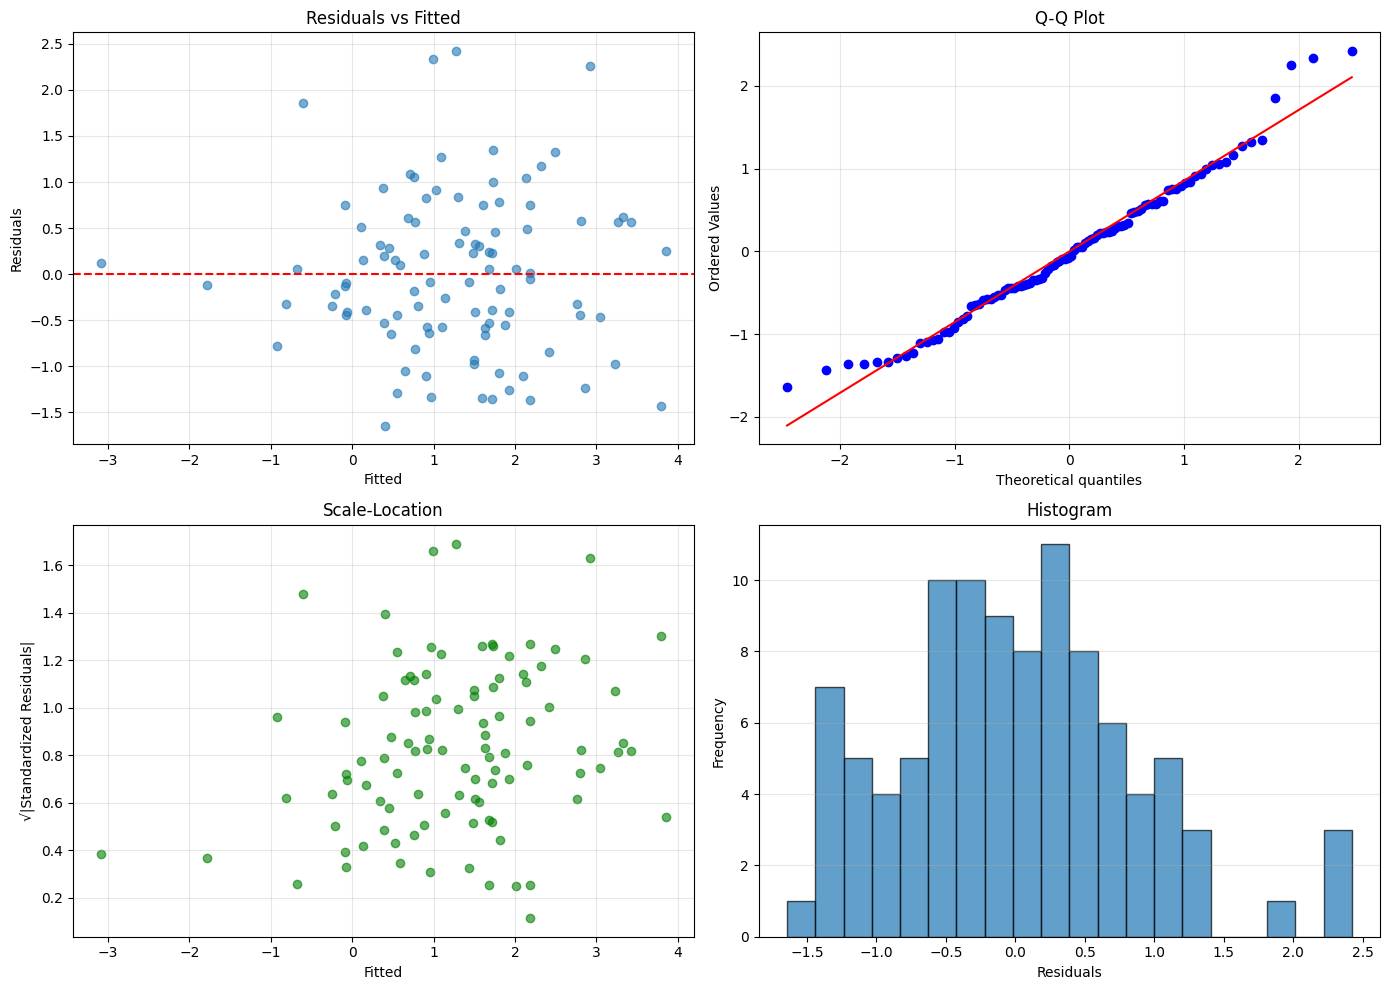

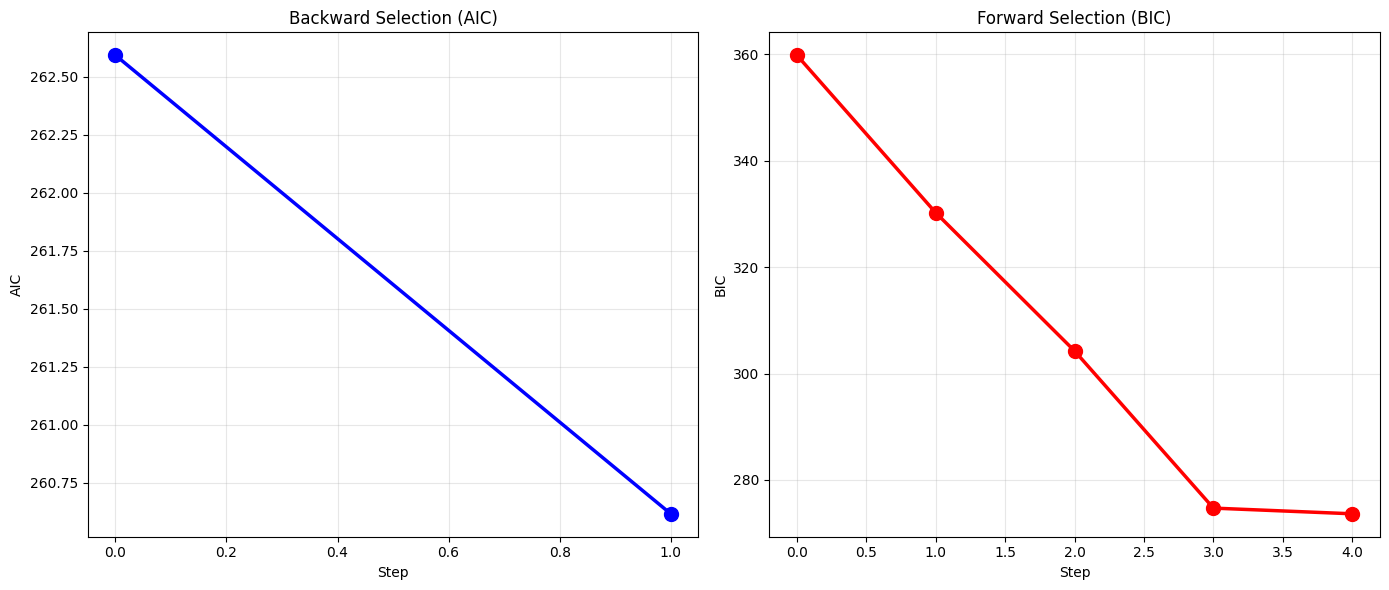

In [19]:
print("RECOMMENDED MODEL")
print()
print(f"Y ~ {' + '.join(sorted(recommended_model['predictors']))}")
print()
print("Coefficients:")
print(f"  Intercept: {recommended_model['coefficients'][0]:.6f}")
for i, pred in enumerate(sorted(recommended_model['predictors'])):
    print(f"  {pred}: {recommended_model['coefficients'][i+1]:+.6f}")

print()
print("Performance:")
print(f"  R² = {recommended_model['r2']:.6f} ({recommended_model['r2']*100:.2f}% variance explained)")
print(f"  Adjusted R² = {recommended_model['adj_r2']:.6f}")
print(f"  AIC = {recommended_model['aic']:.4f} (from log-likelihood)")
print(f"  BIC = {recommended_model['bic']:.4f} (from log-likelihood)")
print(f"  Log-Likelihood = {recommended_model['llf']:.4f}")
print(f"  RMSE = {recommended_model['rmse']:.6f}")

# Excluded predictors
excluded = set(predictors_all) - set(recommended_model['predictors'])
if excluded:
    print()
    print("Excluded predictor(s):")
    for ex in sorted(excluded):
        with_ex = fit_model(X, y, set(recommended_model['predictors']) | {ex})
        print(f"  {ex}: Adding it worsens AIC by {with_ex['aic'] - recommended_model['aic']:+.4f}, BIC by {with_ex['bic'] - recommended_model['bic']:+.4f}")

# Model diagnostics
print("MODEL DIAGNOSTICS")
print()

X_final = X[list(recommended_model['predictors'])].values
beta_final, y_pred_final = fit_ols_model(X_final, y.values)
residuals = y.values - y_pred_final

shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk (normality): W = {shapiro_stat:.6f}, p = {shapiro_p:.6f}")
if shapiro_p > 0.05:
    print(f"   Residuals normally distributed")
else:
    print(f"  Possible deviation from normality")

# Durbin-Watson
dw = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)
print(f"Durbin-Watson (independence): DW = {dw:.4f}")
if 1.5 <= dw <= 2.5:
    print(f"   No concerning autocorrelation")
else:
    print(f"   Possible autocorrelation")

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_pred_final, residuals, alpha=0.6)
axes[0, 0].axhline(0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(y_pred_final, np.sqrt(np.abs(residuals/np.std(residuals))), alpha=0.6, color='green')
axes[1, 0].set_xlabel('Fitted')
axes[1, 0].set_ylabel('√|Standardized Residuals|')
axes[1, 0].set_title('Scale-Location')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Histogram')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Selection paths
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

backward_df = pd.DataFrame(backward_aic_steps)
axes[0].plot(backward_df['step'], backward_df['aic'], 'bo-', linewidth=2.5, markersize=10)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('AIC')
axes[0].set_title('Backward Selection (AIC)')
axes[0].grid(True, alpha=0.3)

forward_df = pd.DataFrame(forward_bic_steps)
axes[1].plot(forward_df['step'], forward_df['bic'], 'ro-', linewidth=2.5, markersize=10)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('BIC')
axes[1].set_title('Forward Selection (BIC)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()